<a href="https://colab.research.google.com/github/PioBasile/ProjetMachineLearning/blob/main/ProjetMachineLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
from google.colab import drive
import pandas as pd
import re
import spacy
"""
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Téléchargement des ressources NLTK nécessaires
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
"""
# Avis de Reyder sur les algo de classification :
# K-NN : nul les tweet on des context different on ne peut pas les classer par similarité
# Naive Bayésiene : Bien, on a des classes précises et distincte
# Arbre décisionnel : Pas mal, mais il faudrait faire plein de sous classifications

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##Sac de mots

In [34]:
path = '/content/drive/MyDrive/ColabNotebooks/scitweets_export.tsv'

from sklearn.feature_extraction.text import CountVectorizer


df = pd.read_csv(path, sep='\t')

#Code du cours
vectorizer = CountVectorizer(lowercase=False, stop_words="english", min_df=2, max_df=0.8, ngram_range=(1,1))
X = vectorizer.fit_transform(df["text"])

vocabulaire = vectorizer.get_feature_names_out()
print(vocabulaire[300:310])

print(X.shape)

#lowercase=False: Ne convertit pas en minuscules (respecte la casse).
#stop_words="english": Supprime les mots courants anglais (mots vides).
#min_df=2: Ignore les mots apparaissant dans moins de 2 documents.
#max_df=0.8: Ignore les mots apparaissant dans plus de 80% des documents.
#ngram_range=(1,1): N'extrait que des mots uniques (unigrammes).


['Indonesia' 'Industry' 'Instead' 'Institute' 'Interesting'
 'International' 'Iran' 'Is' 'Islam' 'Israel']
(1140, 1905)


##Pondération des mots

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer


df = pd.read_csv(path, sep='\t')

#Code du cours
vectorizer = TfidfVectorizer(norm="l2",sublinear_tf=True,min_df=2, max_df=0.8, max_features=5000,ngram_range=(1,2))
X = vectorizer.fit_transform(df["text"])

vocabulaire = vectorizer.get_feature_names_out()
print(vocabulaire[300:310])

print(X.shape)

#norm="l2": Applique une normalisation L2 aux vecteurs TF-IDF.
#sublinear_tf=True: Applique une mise à l'échelle sous-linéaire à la fréquence des termes (1 + log(tf)).
#min_df=2: Ignore les mots apparaissant dans moins de 2 documents.
#max_df=0.8: Ignore les mots apparaissant dans plus de 80% des documents.
#max_features=5000: Limite le vocabulaire aux 5000 termes les plus fréquents.
#ngram_range=(1,2): Extrait des mots seuls (unigrammes) et des paires de mots (bigrammes).

['be using' 'be very' 'beaten' 'beaten by' 'beautiful' 'beauty' 'because'
 'because of' 'become' 'becomes']
(1140, 3129)


##Division de la data pour les tests


In [36]:
Y = df[['science_related', 'scientific_claim', 'scientific_reference', 'scientific_context']]
print(Y.head())

   science_related  scientific_claim  scientific_reference  scientific_context
0                0               0.0                   0.0                 0.0
1                0               0.0                   0.0                 0.0
2                1               1.0                   0.0                 0.0
3                1               1.0                   0.0                 0.0
4                1               1.0                   0.0                 0.0


In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("Variable entrainement:", X_train.shape)
print("Variable tests:", X_test.shape)
print("Variable entrainement resultat:", y_train.shape)
print("Variable entrainement resultat des tests:", y_test.shape)


Variable entrainement: (912, 1905)
Variable tests: (228, 1905)
Variable entrainement resultat: (912, 4)
Variable entrainement resultat des tests: (228, 4)


##Arbre de décision


In [42]:
from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier(random_state=42)

classifier.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [43]:
y_pred = classifier.predict(X_test)
print(y_pred.shape)
print(y_pred[0:5])

(228, 4)
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [1. 0. 1. 1.]
 [0. 0. 0. 0.]
 [1. 0. 1. 1.]]


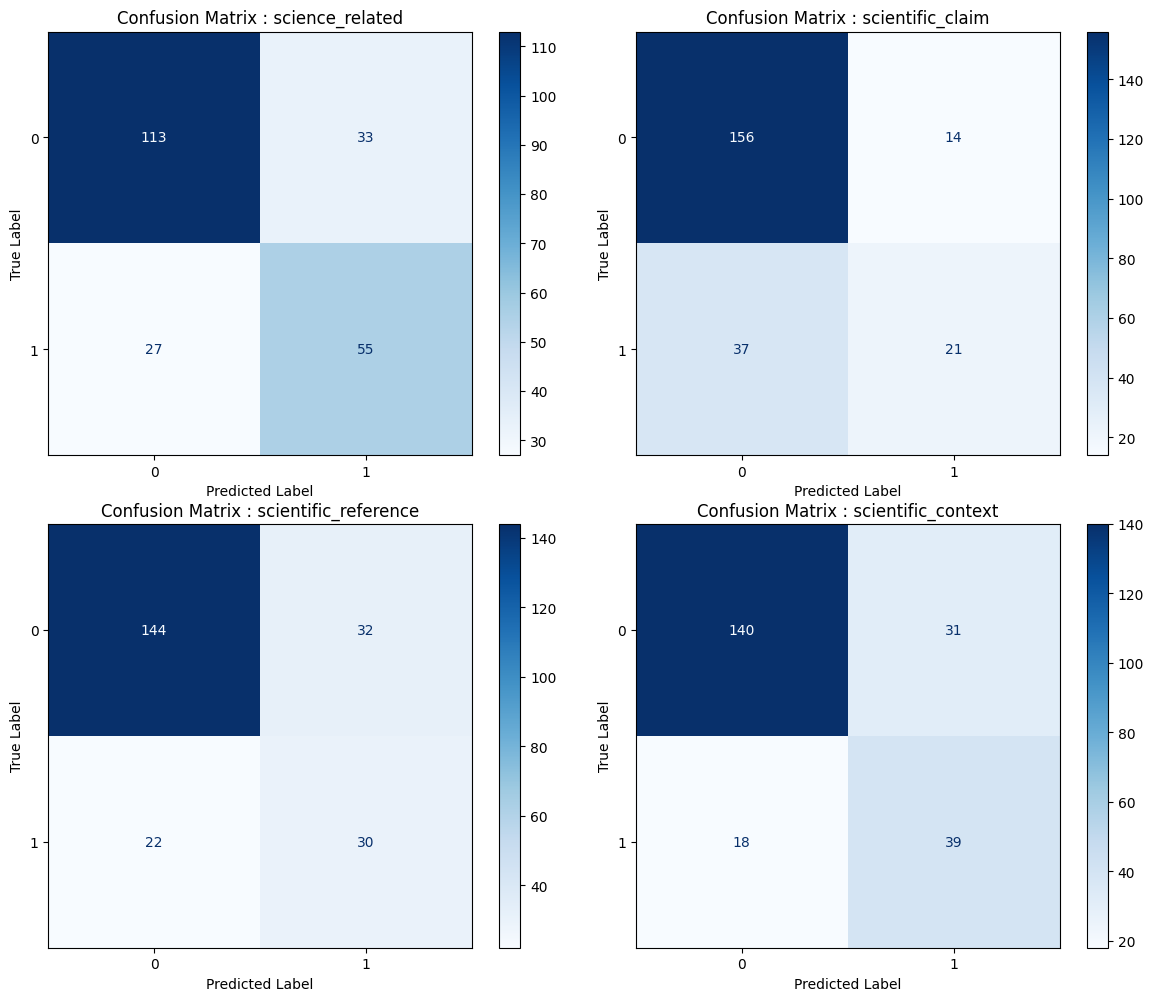

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_test_np = y_test.to_numpy()

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, label in enumerate(y_test.columns):
    cm = confusion_matrix(y_test_np[:, i], y_pred[:, i])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(ax=axes[i], cmap=plt.cm.Blues)
    axes[i].set_title(f'Confusion Matrix : {label}')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()

#En haut à gauche (True 0, Predicted 0)
#En haut à droite (True 0, Predicted 1)
#En bas à gauche (True 1, Predicted 0)
#En bas à droite (True 1, Predicted 1)
